In [1]:
# NOTEBOOK 2: Statistical & Classical Time Series Models
# Models: ARIMA, SARIMA, SARIMAX, Prophet
# Dataset: Store Item Demand Forecasting (Kaggle)
# Author: Nabin Katwal | Retail Demand Forecasting Portfolio Project
#
# NOTE: These models train per store-item series.
#       We use Store 1, Item 1 for illustration, then show how to loop.

In [3]:
# nstall Libraries
!pip install statsmodels prophet pmdarima joblib

   ---------------------------------------- 0.0/719.3 kB ? eta -:--:--
   ---------------------------------------- 719.3/719.3 kB 7.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 27.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------

In [4]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
warnings.filterwarnings("ignore")
 
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
 
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
 
from sklearn.metrics import mean_absolute_error, mean_squared_error
 
plt.rcParams["figure.figsize"] = (14, 5)
os.makedirs("saved_models", exist_ok=True)
 
print("Libraries imported")

Libraries imported


In [5]:
# Load Data
train = pd.read_csv("train.csv")
train["date"] = pd.to_datetime(train["date"])
 
print("Train shape:", train.shape)
print("Date range:", train["date"].min(), "→", train["date"].max())
print("Stores:", train["store"].nunique(), "| Items:", train["item"].nunique())

Train shape: (913000, 4)
Date range: 2013-01-01 00:00:00 → 2017-12-31 00:00:00
Stores: 10 | Items: 50


In [6]:
# Extract One Series (Store 1, Item 1)
series = (
    train[(train["store"] == 1) & (train["item"] == 1)]
    .set_index("date")["sales"]
    .asfreq("D")
    .sort_index()
)
 
print(f"Series length: {len(series)} days")
print(series.tail())

Series length: 1826 days
date
2017-12-27    14
2017-12-28    19
2017-12-29    15
2017-12-30    27
2017-12-31    23
Freq: D, Name: sales, dtype: int64


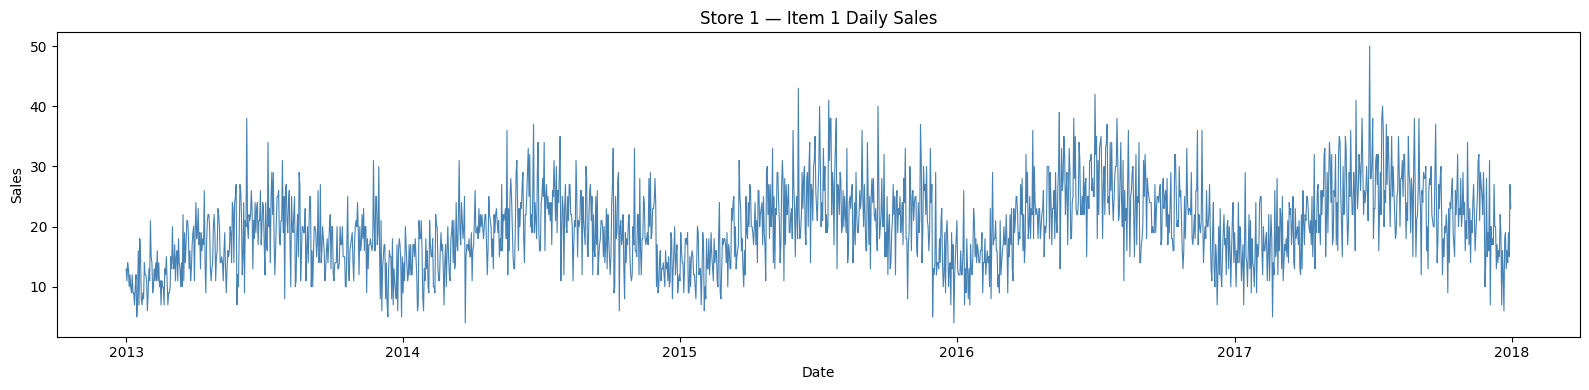

In [7]:
# Plot the series
plt.figure(figsize=(16, 4))
plt.plot(series, color="steelblue", linewidth=0.8)
plt.title("Store 1 — Item 1 Daily Sales")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [11]:
# Stationarity Tests
def adf_test(ts, label="Series"):
    result = adfuller(ts.dropna())
    print(f"\nADF Test: {label} ")
    print(f"  Test Stat : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    print(f"  Stationary: {'YES' if result[1] < 0.05 else 'NO'}")

In [12]:
adf_test(series, "Original")


ADF Test: Original 
  Test Stat : -3.1577
  p-value   : 0.0226
  Stationary: YES


In [13]:
def kpss_test(ts, label="Series"):
    stat, p, _, _ = kpss(ts.dropna(), regression="c", nlags="auto")
    print(f"\nKPSS Test: {label} ")
    print(f"  Test Stat : {stat:.4f}")
    print(f"  p-value   : {p:.4f}")
    print(f"  Stationary: {'YES' if p > 0.05 else 'NO'}")

In [14]:
kpss_test(series, "Original")


KPSS Test: Original 
  Test Stat : 1.8914
  p-value   : 0.0100
  Stationary: NO


C:\Windows\Temp\ipykernel_28064\1510712980.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, _, _ = kpss(ts.dropna(), regression="c", nlags="auto")


In [15]:
# First-order differencing
series_diff = series.diff(1).dropna()
adf_test(series_diff, "After 1st Differencing")
kpss_test(series_diff, "After 1st Differencing")


ADF Test: After 1st Differencing 
  Test Stat : -12.6768
  p-value   : 0.0000
  Stationary: YES

KPSS Test: After 1st Differencing 
  Test Stat : 0.0333
  p-value   : 0.1000
  Stationary: YES


C:\Windows\Temp\ipykernel_28064\1510712980.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, _, _ = kpss(ts.dropna(), regression="c", nlags="auto")


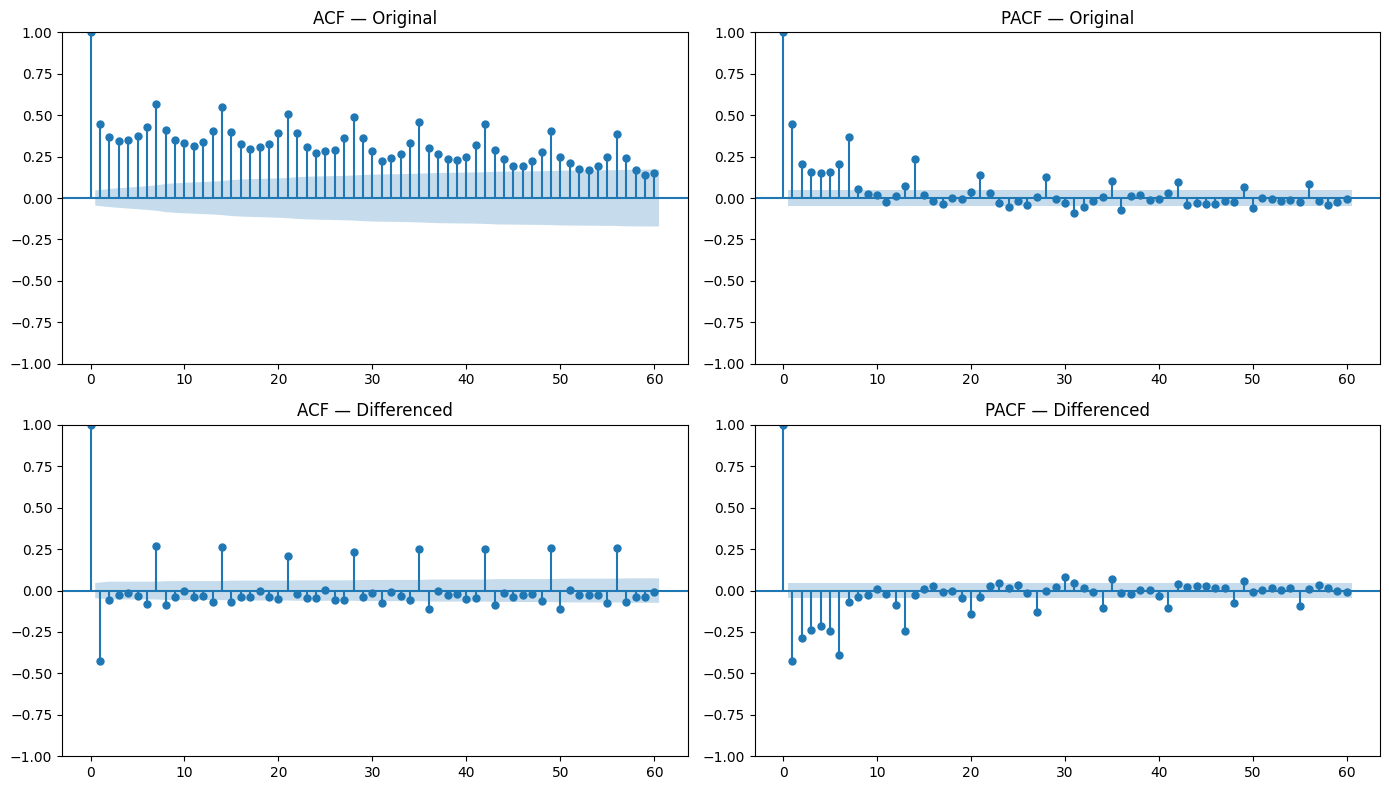

In [16]:
# ACF & PACF Plots (help choose p, q for ARIMA)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
 
plot_acf(series,      lags=60, ax=axes[0, 0], title="ACF — Original")
plot_pacf(series,     lags=60, ax=axes[0, 1], title="PACF — Original")
plot_acf(series_diff, lags=60, ax=axes[1, 0], title="ACF — Differenced")
plot_pacf(series_diff,lags=60, ax=axes[1, 1], title="PACF — Differenced")
 
plt.tight_layout()
plt.show()

In [17]:
# Train / Test Split for Time Series Models
# Use last 90 days as validation
split_date = "2017-10-01"
 
train_ts = series[:split_date]
val_ts   = series[split_date:]
 
print(f"Train series: {len(train_ts)} days")
print(f"Val   series: {len(val_ts)}   days")
 
# Helper to evaluate
def ts_evaluate(model_name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = np.mean(
        200 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true) + 1e-8)
    )
    print(f"\n{'='*40}")
    print(f"Model : {model_name}")
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"SMAPE : {smape:.2f}%")
    print(f"{'='*40}")
    return {"Model": model_name, "MAE": round(mae, 4),
            "RMSE": round(rmse, 4), "SMAPE": round(smape, 2)}
 
results_ts = []

Train series: 1735 days
Val   series: 92   days


Training ARIMA(2,1,2)...
                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1735
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -5374.552
Date:                Wed, 03 Jun 2026   AIC                          10759.103
Time:                        07:20:21   BIC                          10786.394
Sample:                    01-01-2013   HQIC                         10769.196
                         - 10-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7509      0.126     -5.959      0.000      -0.998      -0.504
ar.L2          0.0227      0.034      0.675      0.499      -0.043       0.089
ma.L1         -0.0946      

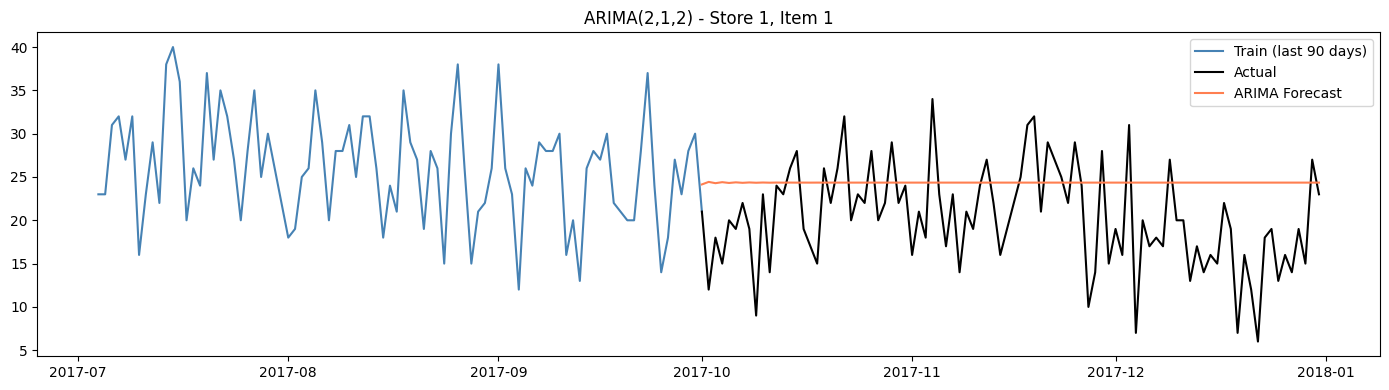

ARIMA model saved


In [18]:
# MODEL 1: ARIMA
# p = AR order (from PACF), d = differencing, q = MA order (from ACF)
# Based on ACF/PACF: p=2, d=1, q=2 is a reasonable start

print("Training ARIMA(2,1,2)...")
arima_model = ARIMA(train_ts, order=(2, 1, 2))
arima_fit   = arima_model.fit()
 
print(arima_fit.summary())
 
# Forecast validation period
arima_forecast = arima_fit.forecast(steps=len(val_ts))
arima_forecast = np.clip(arima_forecast, 0, None)
 
metrics = ts_evaluate("ARIMA(2,1,2)", val_ts.values, arima_forecast)
results_ts.append(metrics)
 
# Plot
plt.figure(figsize=(14, 4))
plt.plot(train_ts[-90:], label="Train (last 90 days)", color="steelblue")
plt.plot(val_ts,         label="Actual", color="black")
plt.plot(val_ts.index,   arima_forecast, label="ARIMA Forecast", color="coral")
plt.title("ARIMA(2,1,2) - Store 1, Item 1")
plt.legend()
plt.tight_layout()
plt.show()
 
# Save
joblib.dump(arima_fit, "saved_models/arima_store1_item1.pkl")
print("ARIMA model saved")

In [19]:
# Auto ARIMA (optional — finds best p,d,q automatically)

In [20]:
from pmdarima import auto_arima
auto_model = auto_arima(train_ts, seasonal=False, stepwise=True,
                        suppress_warnings=True, error_action="ignore")
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1735
Model:               SARIMAX(4, 1, 5)   Log Likelihood               -5226.896
Date:                Wed, 03 Jun 2026   AIC                          10473.791
Time:                        07:22:01   BIC                          10528.373
Sample:                    01-01-2013   HQIC                         10493.977
                         - 10-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5172      0.027    -19.340      0.000      -0.570      -0.465
ar.L2          0.2523      0.014     18.120      0.000       0.225       0.280
ar.L3         -0.5795      0.013    -45.093      0.0

Training SARIMA(1,1,1)(1,1,0,7)...
                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                 1735
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 7)   Log Likelihood               -5357.669
Date:                            Wed, 03 Jun 2026   AIC                          10723.338
Time:                                    07:22:03   BIC                          10745.136
Sample:                                01-01-2013   HQIC                         10731.404
                                     - 10-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0668      0.024      2.762      0.006       0.019       0.114


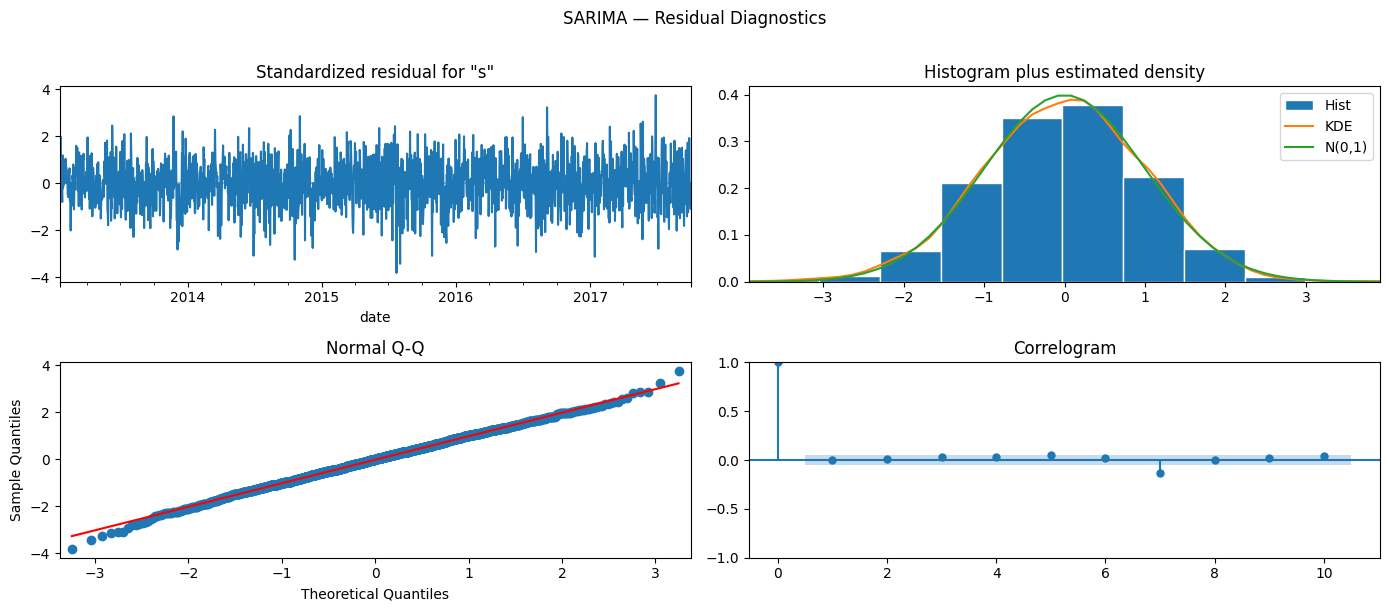

In [21]:
#  MODEL 2: SARIMA
# SARIMA(p,d,q)(P,D,Q,s)  where s=7 for weekly seasonality
# Using smaller seasonal order to keep training fast

print("Training SARIMA(1,1,1)(1,1,0,7)...")
sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 7),   # weekly seasonal period
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
 
print(sarima_fit.summary())
 
# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(val_ts))
sarima_forecast = np.clip(sarima_forecast, 0, None)
 
metrics = ts_evaluate("SARIMA(1,1,1)(1,1,0,7)", val_ts.values, sarima_forecast)
results_ts.append(metrics)
 
# Residual diagnostics
sarima_fit.plot_diagnostics(figsize=(14, 6))
plt.suptitle("SARIMA — Residual Diagnostics", y=1.01)
plt.tight_layout()
plt.show()

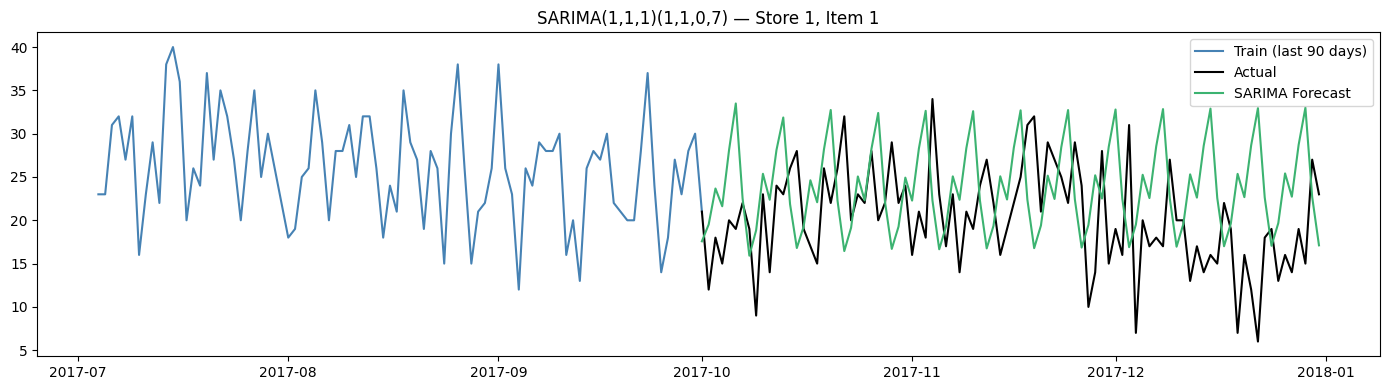

SARIMA model saved


In [22]:
# Plot
plt.figure(figsize=(14, 4))
plt.plot(train_ts[-90:], label="Train (last 90 days)", color="steelblue")
plt.plot(val_ts,         label="Actual", color="black")
plt.plot(val_ts.index,   sarima_forecast, label="SARIMA Forecast", color="mediumseagreen")
plt.title("SARIMA(1,1,1)(1,1,0,7) — Store 1, Item 1")
plt.legend()
plt.tight_layout()
plt.show()
 
joblib.dump(sarima_fit, "saved_models/sarima_store1_item1.pkl")
print("SARIMA model saved")

In [23]:
# MODEL 3: SARIMAX (with external regressors)
# Exogenous variable: day of week (0–6) as a simple external regressor
# In real food demand forecasting you'd add weather, holidays, events, etc.

def get_exog(ts_index):
    df = pd.DataFrame({"date": ts_index})
    df["dayofweek"] = pd.to_datetime(df["date"]).dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["month"]      = pd.to_datetime(df["date"]).dt.month
    return df[["dayofweek", "is_weekend", "month"]].values
 
exog_train = get_exog(train_ts.index)
exog_val   = get_exog(val_ts.index)
 
print("Training SARIMAX(1,1,1)(1,1,0,7) with exogenous features...")
sarimax_model = SARIMAX(
    train_ts,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)
 
print(sarimax_fit.summary())

Training SARIMAX(1,1,1)(1,1,0,7) with exogenous features...
                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                 1735
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 7)   Log Likelihood               -5357.662
Date:                            Wed, 03 Jun 2026   AIC                          10729.325
Time:                                    07:22:26   BIC                          10767.471
Sample:                                01-01-2013   HQIC                         10743.439
                                     - 10-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          2.379e-09   5.88e-06      0.000      1.000

In [24]:
# Forecast with exogenous regressors
sarimax_forecast = sarimax_fit.forecast(steps=len(val_ts), exog=exog_val)
sarimax_forecast = np.clip(sarimax_forecast, 0, None)
 
metrics = ts_evaluate("SARIMAX(1,1,1)(1,1,0,7)+exog", val_ts.values, sarimax_forecast)
results_ts.append(metrics)


Model : SARIMAX(1,1,1)(1,1,0,7)+exog
MAE   : 7.5197
RMSE  : 9.1032
SMAPE : 35.06%


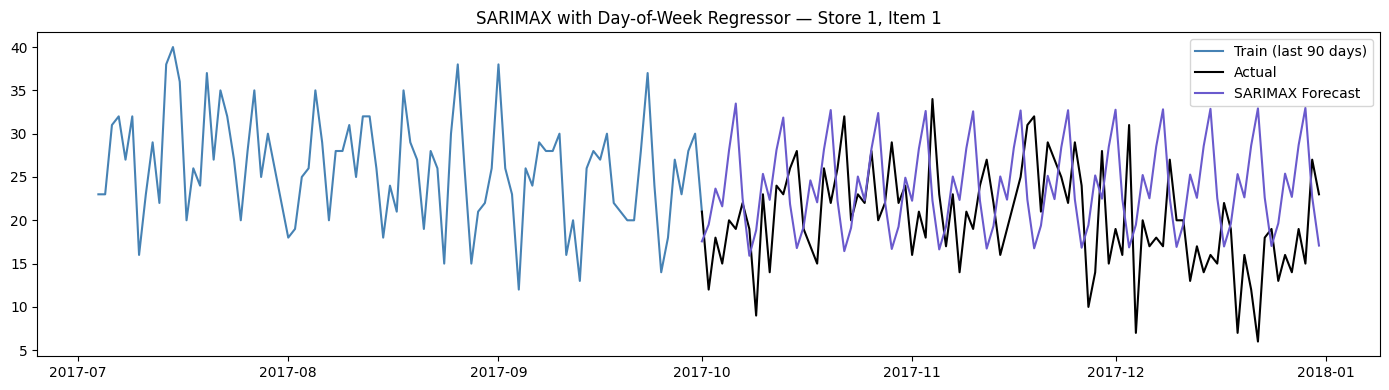

SARIMAX model saved


In [25]:
# Plot
plt.figure(figsize=(14, 4))
plt.plot(train_ts[-90:], label="Train (last 90 days)", color="steelblue")
plt.plot(val_ts,         label="Actual", color="black")
plt.plot(val_ts.index,   sarimax_forecast, label="SARIMAX Forecast", color="slateblue")
plt.title("SARIMAX with Day-of-Week Regressor — Store 1, Item 1")
plt.legend()
plt.tight_layout()
plt.show()
 
joblib.dump(sarimax_fit, "saved_models/sarimax_store1_item1.pkl")
print("SARIMAX model saved")

Training Prophet model...


07:23:00 - cmdstanpy - INFO - Chain [1] start processing
07:23:00 - cmdstanpy - INFO - Chain [1] done processing



Model : Prophet
MAE   : 3.8053
RMSE  : 4.5656
SMAPE : 20.24%


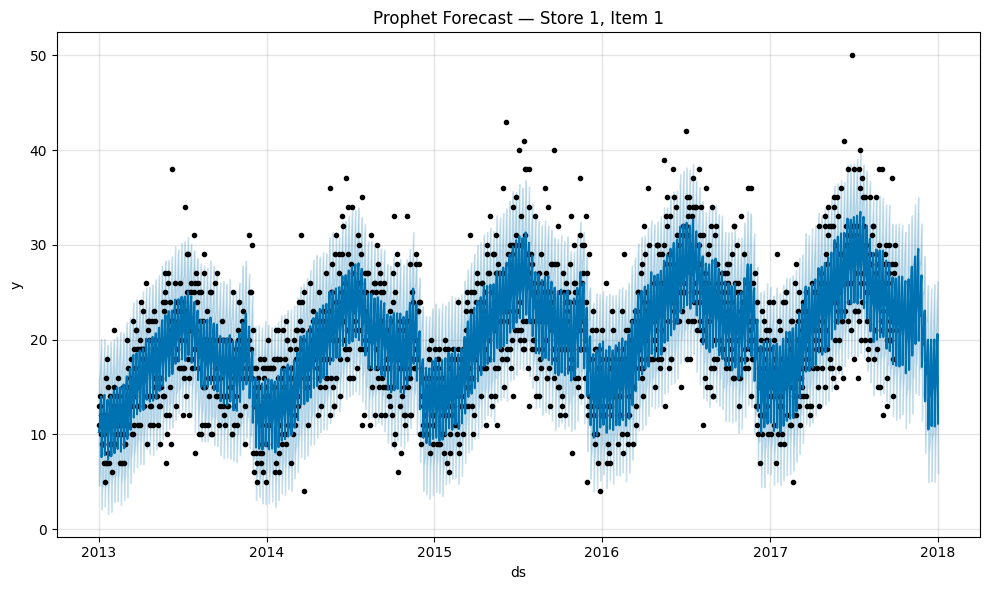

In [26]:
# MODEL 4: Prophet
# Prophet expects columns: 'ds' (date), 'y' (target)
 
prophet_train_df = train_ts.reset_index()
prophet_train_df.columns = ["ds", "y"]
 
# Validation period
prophet_val_df = val_ts.reset_index()
prophet_val_df.columns = ["ds", "y"]
 
print("Training Prophet model...")
prophet_model = Prophet(
    seasonality_mode="multiplicative",   # good for growing time series
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,        # flexibility of trend changes
    seasonality_prior_scale=10.0         # flexibility of seasonality
)
 
# Add custom monthly seasonality
prophet_model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
 
prophet_model.fit(prophet_train_df)
 
# Create future dataframe for validation dates
future = prophet_model.make_future_dataframe(periods=len(val_ts), freq="D")
forecast = prophet_model.predict(future)
 
# Extract validation period predictions
val_forecast = forecast.set_index("ds").loc[val_ts.index, "yhat"]
val_forecast = np.clip(val_forecast.values, 0, None)
 
metrics = ts_evaluate("Prophet", val_ts.values, val_forecast)
results_ts.append(metrics)
 
# Prophet built-in plots
fig1 = prophet_model.plot(forecast)
plt.title("Prophet Forecast — Store 1, Item 1")
plt.tight_layout()
plt.show()

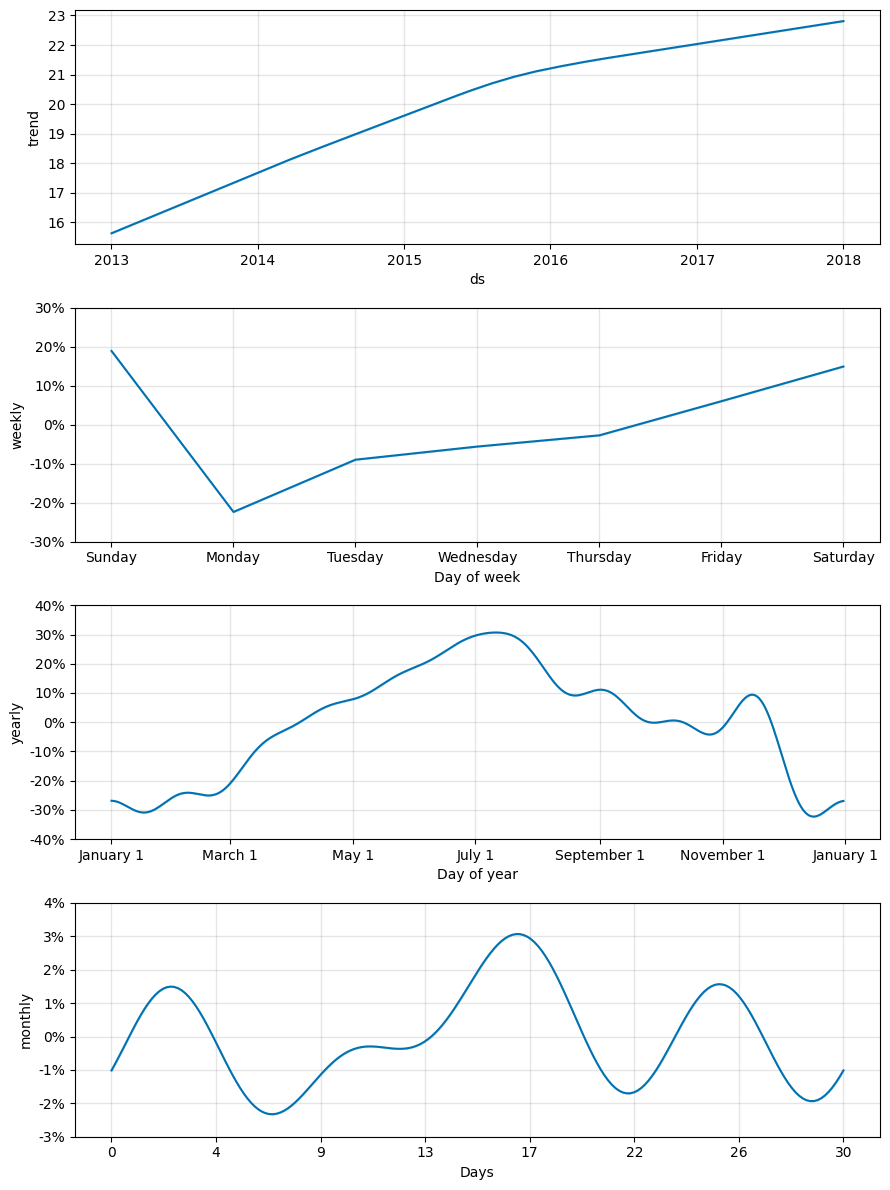

In [27]:
fig2 = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.show()

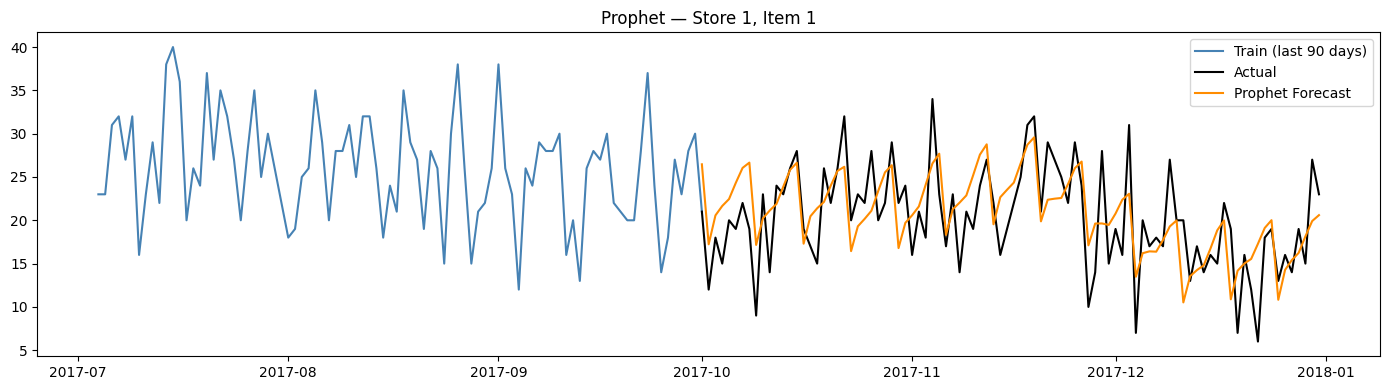

In [28]:
# Custom actual vs predicted plot
plt.figure(figsize=(14, 4))
plt.plot(train_ts[-90:],   label="Train (last 90 days)", color="steelblue")
plt.plot(val_ts,           label="Actual", color="black")
plt.plot(val_ts.index, val_forecast, label="Prophet Forecast", color="darkorange")
plt.title("Prophet — Store 1, Item 1")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Save Prophet model
import pickle
with open("saved_models/prophet_store1_item1.pkl", "wb") as f:
    pickle.dump(prophet_model, f)
print("Prophet model saved")

Prophet model saved


In [30]:
# Prophet Cross Validation (optional — takes time)
# cv_results = cross_validation(
#     prophet_model,
#     initial="730 days",
#     period="90 days",
#     horizon="90 days"
# )
# perf = performance_metrics(cv_results)
# print(perf[["horizon", "mae", "rmse", "mape"]].head(10))

In [31]:
# Model Comparison Table
results_df = pd.DataFrame(results_ts).sort_values("RMSE")
print("\n" + "=" * 60)
print("STATISTICAL MODEL COMPARISON — Store 1, Item 1 Validation")
print("=" * 60)
print(results_df.to_string(index=False))


STATISTICAL MODEL COMPARISON — Store 1, Item 1 Validation
                       Model    MAE   RMSE  SMAPE
                     Prophet 3.8053 4.5656  20.24
                ARIMA(2,1,2) 5.8591 7.1349  28.85
SARIMAX(1,1,1)(1,1,0,7)+exog 7.5197 9.1032  35.06
      SARIMA(1,1,1)(1,1,0,7) 7.5263 9.1119  35.08


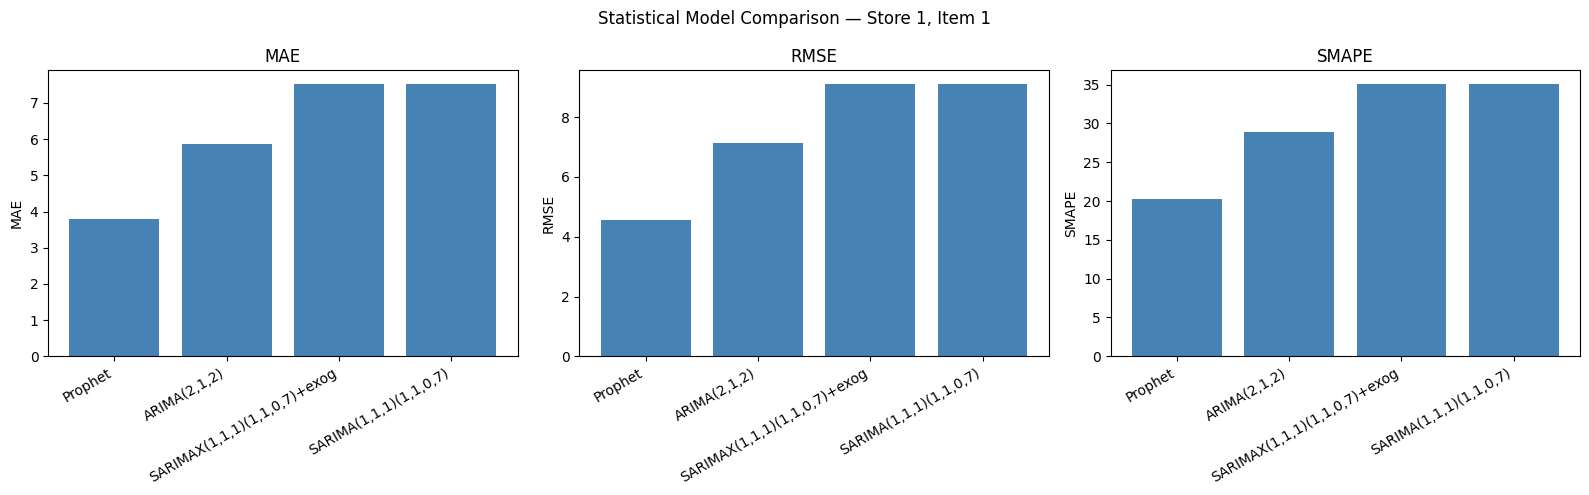

In [32]:
# Bar plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metric in enumerate(["MAE", "RMSE", "SMAPE"]):
    axes[i].bar(results_df["Model"], results_df[metric], color="steelblue")
    axes[i].set_title(metric)
    axes[i].set_xticklabels(results_df["Model"], rotation=30, ha="right")
    axes[i].set_ylabel(metric)
 
plt.suptitle("Statistical Model Comparison — Store 1, Item 1")
plt.tight_layout()
plt.show()

In [33]:
# How to Scale: Loop Over All Store-Item Pairs (template)
# This shows the structure for training Prophet for all 500 store-item combos.
# Full run can take hours — use parallel execution in production.

In [36]:
print("""
Scaling Template 
To train Prophet for all store-item pairs:
 
all_metrics = []
models_dir = "saved_models/prophet_all"
os.makedirs(models_dir, exist_ok=True)
 
for store in train["store"].unique():
    for item in train["item"].unique():
        key = f"store{store}_item{item}"
 
        # Extract series
        ts = (
            train[(train["store"] == store) & (train["item"] == item)]
            .set_index("date")["sales"]
            .asfreq("D")
            .sort_index()
        )
 
        # Train / val split
        ts_train = ts[:"2017-09-30"]
        ts_val   = ts["2017-10-01":]
 
        # Prophet DataFrame
        df_p = ts_train.reset_index()
        df_p.columns = ["ds", "y"]
 
        # Train
        m = Prophet(seasonality_mode="multiplicative", yearly_seasonality=True,
                    weekly_seasonality=True, changepoint_prior_scale=0.05)
        m.fit(df_p)
 
        # Forecast
        future = m.make_future_dataframe(periods=len(ts_val), freq="D")
        fc = m.predict(future)
        preds = fc.set_index("ds").loc[ts_val.index, "yhat"].clip(lower=0).values
 
        # Metrics
        mae  = mean_absolute_error(ts_val.values, preds)
        rmse = np.sqrt(mean_squared_error(ts_val.values, preds))
        all_metrics.append({"store": store, "item": item, "MAE": mae, "RMSE": rmse})
 
        # Save
        with open(f"{models_dir}/{key}.pkl", "wb") as f:
            pickle.dump(m, f)
 
all_metrics_df = pd.DataFrame(all_metrics)
print(all_metrics_df.groupby("store")[["MAE", "RMSE"]].mean())
""")
 
print("\n Notebook 2 Complete!")
print("Saved models:")
for fname in os.listdir("saved_models"):
    print(" •", fname)


Scaling Template 
To train Prophet for all store-item pairs:
 
all_metrics = []
models_dir = "saved_models/prophet_all"
os.makedirs(models_dir, exist_ok=True)
 
for store in train["store"].unique():
    for item in train["item"].unique():
        key = f"store{store}_item{item}"
 
        # Extract series
        ts = (
            train[(train["store"] == store) & (train["item"] == item)]
            .set_index("date")["sales"]
            .asfreq("D")
            .sort_index()
        )
 
        # Train / val split
        ts_train = ts[:"2017-09-30"]
        ts_val   = ts["2017-10-01":]
 
        # Prophet DataFrame
        df_p = ts_train.reset_index()
        df_p.columns = ["ds", "y"]
 
        # Train
        m = Prophet(seasonality_mode="multiplicative", yearly_seasonality=True,
                    weekly_seasonality=True, changepoint_prior_scale=0.05)
        m.fit(df_p)
 
        # Forecast
        future = m.make_future_dataframe(periods=len(ts_val), freq="D")
        fc =